In [45]:
using Plots,JLD2,LinearAlgebra

In [46]:
Nx=12
Ny=12
tper=-0.37

tpa=2.0
tNNN=-0.08

α=-1.5
temp=0.09
β=0.15
K=1.0;
KNNN=0.0;
gshear=0.1
trytime_record=1

filling=1.25
#trytime=1

1.25

In [47]:
st=load("test.jld2")
   

Dict{String, Any} with 14 entries:
  "Eelec"          => -2.38415
  "grad"           => [0.000274994, -0.000271754, 0.000259414, -0.000264929, 0.…
  "spectrum"       => [-4.74191, -4.74035, -4.64277, -4.64277, -4.6418, -4.6418…
  "max_record"     => 0.051425
  "average_record" => 0.0342576
  "record_cal"     => Vector{Any}[[-2.37412, -2.37702, -2.36834, -2.35884, -2.3…
  "orbital_id"     => [1 13 … 121 133; 2 14 … 122 134; … ; 11 23 … 131 143; 12 …
  "phonon_id"      => [1 13 … 121 133; 2 14 … 122 134; … ; 11 23 … 131 143; 12 …
  "phonon_coor"    => [5.68041e-5, 6.62068e-5, -0.000343536, 0.000234334, -0.00…
  "FL"             => 1.44415
  "ave_npa"        => 180.0
  "E_total"        => -2.38153
  "Egap"           => 0.0583009
  "free_energy"    => -2.38407

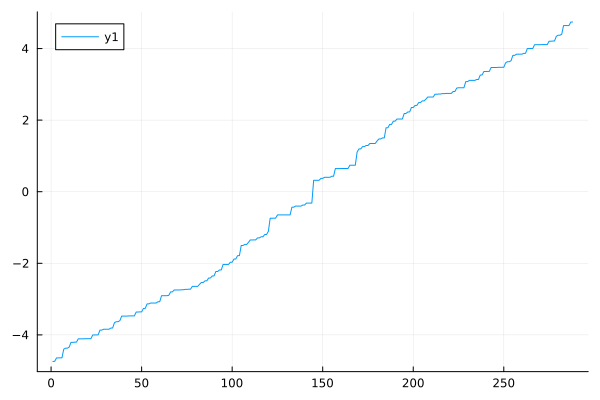

In [48]:
plot(sort(st["spectrum"]))

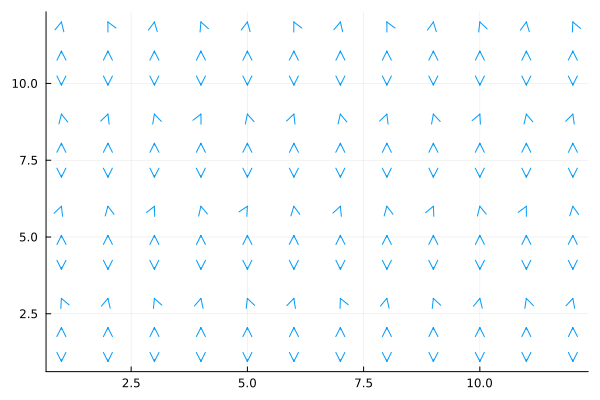

In [49]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end

dis_x=dis_x .- atom_x
dis_y=dis_y .- atom_y
p1=quiver(vec(atom_x),vec(atom_y),quiver=(vec(dis_x),vec(dis_y)))




In [50]:
#savefig(p1,"quiverplot.png")

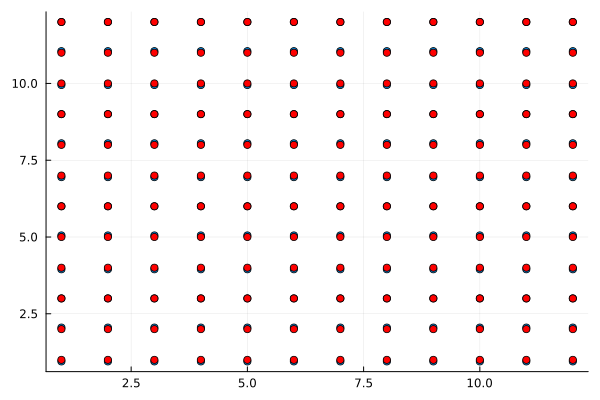

In [51]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end


p2=scatter(vec(dis_x),vec(dis_y))
scatter!(vec(atom_x),vec(atom_y),color=:red,legend=:false)

In [52]:
#savefig(p2,"atomplot.png")

In [53]:
sort(vec(dis_y)-vec(atom_y))

144-element Vector{Float64}:
 -0.05142497653408107
 -0.05142244566457832
 -0.05141317408126245
 -0.051413125090999046
 -0.051412767057355424
 -0.051408579748519756
 -0.051405223357896546
 -0.05140481547264919
 -0.05140113837247373
 -0.05139921701849559
  ⋮
  0.05093033008543113
  0.050933996892043254
  0.05093521403063672
  0.05093868095600129
  0.05094193201582442
  0.05094232564479295
  0.050943149770027674
  0.050952091418526635
  0.050954224310726826

In [54]:
sort(vec(sqrt.(dis_x.^2+dis_y.^2)))

144-element Vector{Float64}:
  1.3784191436003472
  2.21362116912139
  2.281844207846055
  2.864583231080427
  3.146077857516439
  3.162672547214943
  3.606034096903953
  3.633874902211026
  4.073232615747883
  4.111171224623863
  ⋮
 14.903774402090967
 15.000380499126118
 15.000424841628487
 15.587732226783853
 15.592273777789462
 15.620814538883328
 16.27920127666091
 16.313456739720497
 16.970814523170212

In [55]:
sum(vec(sqrt.(dis_x.^2+dis_y.^2)))/(Nx*Ny)

9.831442976356286

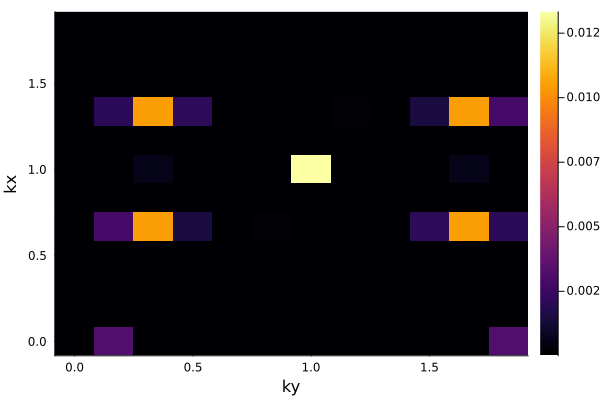

In [56]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_x=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_x[ja,jb]+=phonon_coor[phonon_id[jc,jd,1]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_x),xlabel="ky",ylabel="kx")

In [57]:
sort(vec(abs.(Fourier_mode_x)))

144-element Vector{Float64}:
 1.8973538018496328e-19
 1.4057977093456268e-16
 1.409349796061816e-16
 1.5600561160609447e-16
 1.569318037944839e-16
 2.2827967691893945e-16
 2.5187239568885824e-16
 2.538906491013186e-16
 3.820723546024299e-15
 3.8211786833426756e-15
 ⋮
 0.002798161248506838
 0.0027981612485068435
 0.0031682284740259968
 0.0031682284740259976
 0.010499372975413854
 0.010499372975413862
 0.010499431413904806
 0.010499431413904812
 0.013327293053031224

In [58]:
findmax(abs.(Fourier_mode_x))

(0.013327293053031224, CartesianIndex(7, 7))

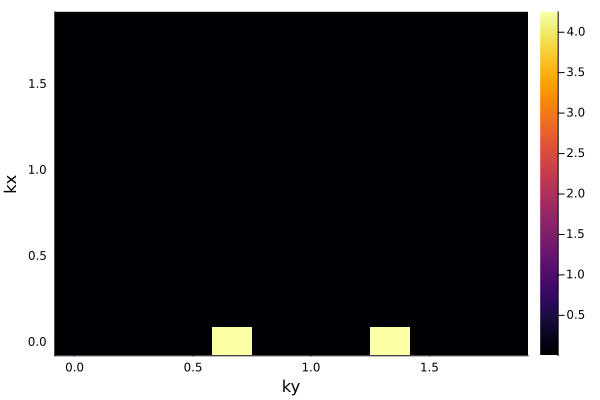

In [59]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_y=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_y[ja,jb]+=phonon_coor[phonon_id[jc,jd,2]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_y),xlabel="ky",ylabel="kx")

In [60]:
findmax(abs.(Fourier_mode_y))

(4.2522480473776, CartesianIndex(1, 5))

In [61]:
Fourier_mode_y[8,14]

BoundsError: BoundsError: attempt to access 12×12 Matrix{ComplexF64} at index [8, 14]

In [62]:
Fourier_mode_x[8,14]

BoundsError: BoundsError: attempt to access 12×12 Matrix{ComplexF64} at index [8, 14]

In [63]:
Fourier_mode_y[14,8]

BoundsError: BoundsError: attempt to access 12×12 Matrix{ComplexF64} at index [14, 8]

In [64]:
Fourier_mode_x[14,8]

BoundsError: BoundsError: attempt to access 12×12 Matrix{ComplexF64} at index [14, 8]

In [65]:
Fourier_mode_y[8,8]

7.287927314587883e-12 - 1.7971562932832657e-13im

In [66]:
Fourier_mode_x[8,8]

4.8402496203789336e-12 + 1.5313027113855904e-14im